In [1]:
import numpy as np
import pyspedas
import fipcore as fpc
import os
import h5py

In [2]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']

# Plasma Beta Calculation

In [25]:
from scipy.constants import mu_0, e

def compute_beta_par(den, t_para, b_mag):
    """Plasma beta profile using parallel temperature."""
    p_para = (den * 1e6) * e * t_para # density in m^3, temperature in K
    p_mag = (b_mag * 1e-9)**2 / (2.0 * mu_0) # magnetic field from nT to T
    return p_para / p_mag

def compute_beta_perp(den, t_perp, b_mag):
    """Plasma beta profile using perpendicular temperature."""
    p_perp = (den * 1e6) * e * t_perp # density in m^3, temperature in K
    p_mag = (b_mag * 1e-9)**2 / (2.0 * mu_0) # magnetic field from nT to T
    return p_perp / p_mag

def compute_beta_scalar(den, t_para, t_perp, b_mag):
    """Plasma beta profile using average temperature."""
    t_avg = (t_para + 2.0 * t_perp) / 3.0
    p_total = (den * 1e6) * e * t_avg # density in m^3, temperature in K
    p_mag = (b_mag * 1e-9)**2 / (2.0 * mu_0) # magnetic field from nT to T
    return p_total / p_mag

In [24]:
from pyspedas.projects import mms
from pyspedas import tplot_rename, get_data
from fipcore.utils.helper_utils import downsample_cad


def compute_beta_profiles(trange, species='e', probe='1', data_rate='brst', 
        level='l2', get_support_data=True, no_update=True):

    spec_tag = 'des' if species == 'e' else 'dis'

    # Variables to load:
    den_var = f'mms{probe}_{spec_tag}_numberdensity_{data_rate}'
    t_para_var = f'mms{probe}_{spec_tag}_temppara_{data_rate}'
    t_perp_var = f'mms{probe}_{spec_tag}_tempperp_{data_rate}'
    bvec_var = f'mms{probe}_fgm_b_gse_{data_rate}_{level}'

    # Loading in density and temperature data from fpi
    mms.fpi(trange= trange, probe=probe, data_rate=data_rate, level=level,
        datatype=f'{spec_tag}-moms', 
        time_clip=True, varnames=[den_var, t_para_var, t_perp_var], 
        get_support_data=get_support_data, no_update=no_update)

    # Loading in magnetic field data from fgm
    mms.fgm(trange=trange, probe=probe, data_rate=data_rate, level=level,
        varnames=bvec_var, time_clip=True, 
        get_support_data=get_support_data, no_update=no_update)

    # Renaming the tplot variables
    tplot_rename(den_var, 'den')
    tplot_rename(t_para_var, 't_para')
    tplot_rename(t_perp_var, 't_perp')
    tplot_rename(bvec_var, 'bvec')

    # Downsampling the fgm data to the fpi cadence
    downsample_cad('bvec', 'den', trange, newname='bvec_ds')

    # Extracting data from tplot variables
    ntime, den = get_data('den')
    _, t_para = get_data('t_para')
    _, t_perp = get_data('t_perp')
    _, bvec = get_data('bvec_ds') # bvec is [Bx, By, Bz, Bmag]
    bmag = bvec[:, 3]

    # Calling the helper functions to compute the individual beta profiles
    beta_par = compute_beta_par(den, t_para, bmag)
    beta_perp = compute_beta_perp(den, t_perp, bmag)
    beta_scalar = compute_beta_scalar(den, t_para, t_perp, bmag)
    
    return beta_par, beta_perp, beta_scalar, ntime

In [16]:
beta_par_e, beta_perp_e, beta_scalar_e, ntime_e = compute_beta_profiles(trange)

23-Jun-26 11:40:28: Searching for local files...
23-Jun-26 11:40:28: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
23-Jun-26 11:40:28: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
23-Jun-26 11:40:28: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
23-Jun-26 11:40:28: The name mms1_des_errorflags_brst is currently not in pyspedas
23-Jun-26 11:40:28: The name mms1_des_compressionloss_brst is currently not in pyspedas
23-Jun-26 11:40:28: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
23-Jun-26 11:40:28: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
23-Jun-26 11:40:28: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
23-Jun-26 11:40:28: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
2

In [17]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime_e[idx])
dt_obj0 = time_datetime(ntime_e[idx-3])
dt_obj1 = time_datetime(ntime_e[idx+3])

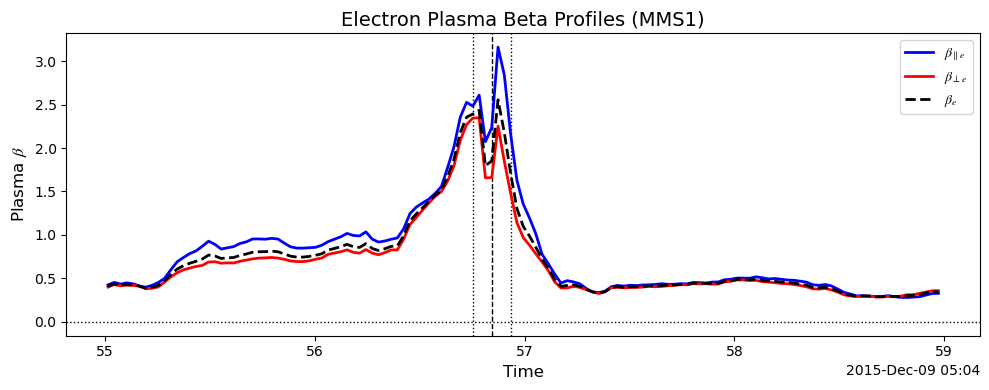

In [18]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

# Convert times
time_dt = time_datetime(ntime_e)

fig, ax = plt.subplots(figsize=(10, 4))

# Plot beta profiles
ax.plot(time_dt, beta_par_e, label=r'$\beta_{\parallel e}$', color='blue', linewidth=2)
ax.plot(time_dt, beta_perp_e, label=r'$\beta_{\perp e}$', color='red', linewidth=2)
ax.plot(time_dt, beta_scalar_e, linestyle='--', label=r'$\beta_{e}$', color='black', linewidth=2)

# Add vertical and horizontal reference lines
ax.axvline(x=dt_obj, color='k', linestyle='dashed', linewidth=1, zorder=0)
ax.axvline(x=dt_obj0, color='k', linestyle='dotted', linewidth=1, zorder=0)
ax.axvline(x=dt_obj1, color='k', linestyle='dotted', linewidth=1, zorder=0)
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=1, zorder=0)

# Set labels and title
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel(r'Plasma $\beta$', fontsize=12)
ax.set_title('Electron Plasma Beta Profiles (MMS1)', fontsize=14)   

# Legend and layout adjustments
ax.legend(loc='best')
fig.tight_layout()

# Render plot
plt.show()

In [19]:
beta_par_i, beta_perp_i, beta_scalar_i, ntime_i = compute_beta_profiles(trange, species='i')

23-Jun-26 11:40:51: Searching for local files...
23-Jun-26 11:40:51: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
23-Jun-26 11:40:51: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
23-Jun-26 11:40:51: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
23-Jun-26 11:40:51: The name mms1_dis_errorflags_brst is currently not in pyspedas
23-Jun-26 11:40:51: The name mms1_dis_compressionloss_brst is currently not in pyspedas
23-Jun-26 11:40:51: The name mms1_dis_pitchangdist_lowen_brst is currently not in pyspedas
23-Jun-26 11:40:51: The name mms1_dis_pitchangdist_miden_brst is currently not in pyspedas
23-Jun-26 11:40:51: The name mms1_dis_pitchangdist_highen_brst is currently not in pyspedas
23-Jun-26 11:40:51: The name mms1_dis_errorflags_brst_moms is currently not in pyspedas
2

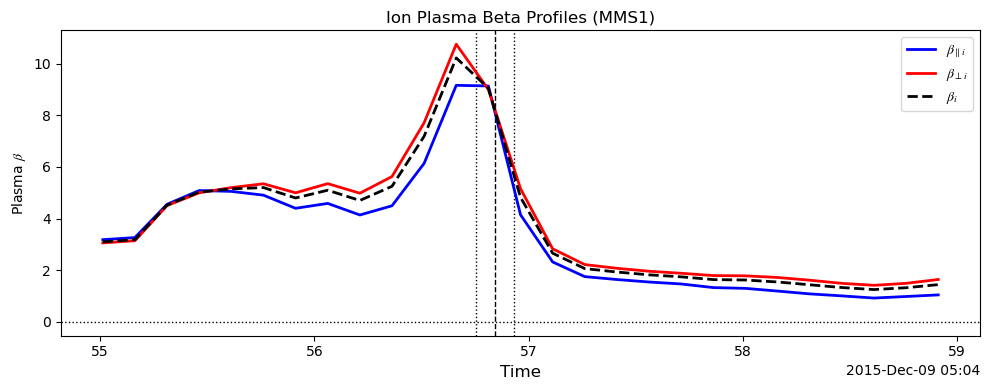

In [20]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

# Convert times
time_dt = time_datetime(ntime_i)

fig, ax = plt.subplots(figsize=(10, 4))

# Plot beta profiles
ax.plot(time_dt, beta_par_i, label=r'$\beta_{\parallel i}$', color='blue', linewidth=2)
ax.plot(time_dt, beta_perp_i, label=r'$\beta_{\perp i}$', color='red', linewidth=2)
ax.plot(time_dt, beta_scalar_i, linestyle='--', label=r'$\beta_{i}$', color='black', linewidth=2)

# Add vertical and horizontal reference lines
ax.axvline(x=dt_obj, color='k', linestyle='dashed', linewidth=1, zorder=0)
ax.axvline(x=dt_obj0, color='k', linestyle='dotted', linewidth=1, zorder=0)
ax.axvline(x=dt_obj1, color='k', linestyle='dotted', linewidth=1, zorder=0)
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=1, zorder=0)

# Set labels and title
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel(r'Plasma $\beta$')
ax.set_title('Ion Plasma Beta Profiles (MMS1)')   

# Legend and layout adjustments
ax.legend(loc='best')
fig.tight_layout()

# Render plot
plt.show()